In [91]:
# Libraries for loading images, building the denoising model, and tensor operations.
from datasets import load_dataset
from torchvision import transforms
from genaibook.core import show_images, get_device
from diffusers import DDPMScheduler, UNet2DModel
from torch.nn import functional as F
import huggingface_hub
import PIL
import torch

In [92]:
# Check the saved Hugging Face credentials; whoami makes a network request.
from huggingface_hub import get_token, whoami

print("Token available:", get_token() is not None)
print("Account:", whoami()["name"])

Token available: True
Account: Petteri9292


In [93]:
# Load the training images from the Hugging Face Hub.
ds = load_dataset("huggan/smithsonian_butterflies_subset",split="train")
# Augment images on access and normalize them for diffusion training.
image_size = 64
preprocess = transforms.Compose([
    # Match the image dimensions expected by the U-Net.
    transforms.Resize((image_size,image_size)),
    # Random flips add variation each time a training image is accessed.
    transforms.RandomHorizontalFlip(),
    # Convert PIL images to channel-first tensors with pixels in [0, 1].
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5]),  # Map pixels to [-1, 1].
])

def transform(examples):
    # Return only tensors so the DataLoader can stack them into batches.
    examples = [preprocess(image) for image in examples["image"]]
    return {"images":examples}
# Apply fresh random augmentation each time an image is retrieved.
ds.set_transform(transform)

# Shuffle the dataset and stack up to 16 images into each batch.
train_dataloader = torch.utils.data.DataLoader(
    ds, batch_size=16, shuffle=True
)

Repo card metadata block was not found. Setting CardData to empty.


In [94]:
# Select the available compute device for the model and image tensors.
device = get_device()
# The U-Net predicts the noise added to an image at a given timestep.
model = UNet2DModel(
    64,  # Spatial image size.
    3,  # Input channels: RGB.
    3,  # Output channels: predicted noise for RGB.
    # Increase feature channels as the encoder reduces spatial resolution.
    block_out_channels=(64,128,256,512),
    # Attention blocks let features use information across image positions.
    down_block_types=("DownBlock2D","DownBlock2D","AttnDownBlock2D","AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D","AttnUpBlock2D","UpBlock2D","UpBlock2D")
).to(device)

print(model.device)

cuda:0


In [95]:
# Define the forward noise schedule and reverse denoising update rule.
scheduler = DDPMScheduler(
    num_train_timesteps=1000,  # Number of noise levels used during training.
    beta_start=0.001,  # Initial variance of the noise added at each step.
    beta_end=0.02  # Final variance of the noise added at each step.
)




In [96]:
from tqdm.auto import tqdm
from torch.nn import functional as Fold
import numpy as np
import torch

# Train for repeated passes through the dataset with AdamW.
epochs = 50
lr = 1e-4
optimizer = torch.optim.AdamW(model.parameters(),lr=lr)
losses = []  # Store one noise-prediction loss per batch.


for epoch in range(epochs):
    # Show batch progress and the latest loss for this epoch.
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}")
    for batch in progress_bar:

        # Move the normalized training images to the model device.
        clean_images = batch["images"].to(device)


        # Sample Gaussian noise independently for every pixel and channel.
        noise = torch.randn_like(clean_images).to(device)

        # Give each image its own random noise level.
        timesteps = torch.randint(
            0,
            scheduler.config.num_train_timesteps,
            (clean_images.shape[0],),
            device=device
        ).long()


        # Mix clean images and noise according to the sampled timesteps.
        noisy_images = scheduler.add_noise(clean_images,noise,timesteps)


        # Learn to predict the added noise using mean squared error.
        noise_pred = model(noisy_images,timesteps,return_dict=False)[0]
        loss = F.mse_loss(noise_pred,noise)

        # Record a scalar loss for plotting and progress reporting.
        loss_value = loss.item()
        losses.append(loss_value)
        progress_bar.set_postfix(loss=f"{loss_value:.4f}")


        # Compute gradients, update model weights, and clear gradients.
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        

Epoch 1/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5/50:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 46/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 47/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/63 [00:00<?, ?it/s]

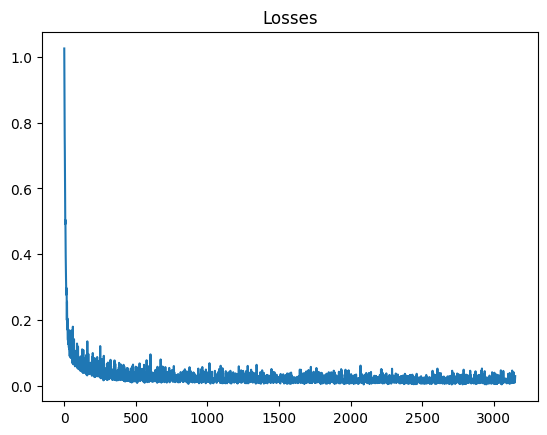

In [100]:
import matplotlib.pyplot as plt



# Plot batch losses in training order to inspect convergence.
plt.title("Losses")
plt.plot(losses)
plt.show()



In [ ]:
# Generate an image without tracking gradients.
with torch.inference_mode():

    # Start with one RGB image of pure Gaussian noise.
    sample = torch.randn(1,3,64,64).to(device)
    # Walk through the schedule from high noise to low noise.
    for t in scheduler.timesteps:
        # Estimate the noise remaining at the current timestep.
        noise_pred = model(sample,t)["sample"]


        # Use that prediction to take one reverse diffusion step.
        sample = scheduler.step(noise_pred,t,sample).prev_sample


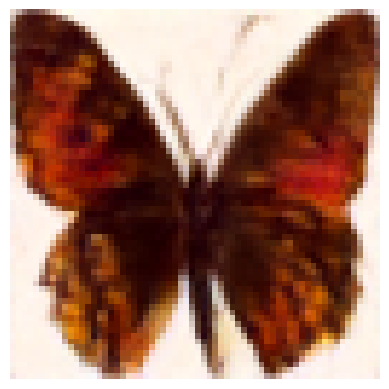

In [111]:
# Convert the first generated image from CHW to HWC and [-1, 1] to [0, 1].
image = (sample[0].detach().cpu().float() / 2 + 0.5).clamp(0, 1)
# Matplotlib expects height, width, channels rather than channels first.
image = image.permute(1, 2, 0).numpy()

# Display the generated RGB image without plot axes.
plt.imshow(image)
plt.axis("off")
plt.show()
